# Module 2 — The Keras autoencoder, step by step (honest edition)

**The problem this solves:** Module 1's XGBoost can only recognise failure
patterns it has **labels** for — it learned from 440 known failures. But a real
fleet also breaks in ways nobody has labelled yet. Module 2 is the safety net:
an **autoencoder** that learns what *normal* looks like for each machine and
raises its hand when a machine stops looking normal — **no labels needed**.

**Explain-like-I'm-5:** imagine a photocopier that has only ever copied
pictures of healthy machines. It gets extremely good at copying those. Hand it
a picture of a machine going wrong and the copy comes out blurry — it has never
seen anything like it. We measure the blurriness (**reconstruction error**)
and use it as the **anomaly score**.

**What was fed in:** for every machine, every Monday, the last **14 days × 14
sensors** (z-scored against that machine's own normal), flattened to 196 numbers.

**The network (Keras/TensorFlow):** `196 → 64 → 16 → 64 → 196` — the middle
**bottleneck of 16** forces it to compress a fortnight into 16 numbers and
rebuild it. Trained on **14,760 healthy training weeks only**.

**Where it trained:** on **Databricks serverless** (2026-07-11) — deep-learning
training belongs on the compute platform, and it sidestepped a local
TensorFlow-in-managed-shells quirk on this Mac. The training notebook is
`databricks_autoencoder.ipynb`; this notebook analyses the scores it produced.

**The headline, up front and honest:** test PR-AUC **0.111** — ~9× better than
random (0.013), clearly better than IsolationForest (0.074), but **it did NOT
beat the simple per-sensor z-score alarm (0.202)**, let alone supervised
XGBoost (0.479). We shipped the comparison anyway — that's the point.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

_start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
for _dir in [_start, *_start.parents]:
    if (_dir / "data" / "raw").exists():
        ML = _dir
        break
plt.style.use(ML.parent / "design" / "fleetpulse.mplstyle")

scores = pd.read_parquet(ML / "data" / "app" / "anomaly_scores.parquet")
meta = json.load(open(ML / "data" / "app" / "anomaly_metrics.json"))
print("windows scored :", f"{len(scores):,}")
print("architecture   :", meta["config"]["architecture"])
print("trained on     :", meta["config"]["trained_on"])
print("training data  :", meta["config"]["training_data"])
scores.head()

Duplicate key in file PosixPath('/Users/shamanth/Desktop/Cursor/Deeksh Personal/fleet-pulse/design/fleetpulse.mplstyle'), line 30 ("axes.prop_cycle: cycler('color', ['0E8A92', '17B9C0', 'C67F14', '5F8B92', '0A4B52', '1F9E78', 'D64545'])")


windows scored : 23,922
architecture   : 196-64-16-64-196 dense, MSE
trained on     : Databricks serverless (2026-07-11), TF via %pip
training data  : healthy train-split windows only (no failure within 14d)


,machine_id,date,split,label,anomaly_score
0,FP-CT-0001,2025-02-24,train,0,0.270194
1,FP-CT-0001,2025-05-12,train,0,0.226987
2,FP-CT-0001,2025-05-05,train,0,0.228118
3,FP-CT-0001,2025-06-09,train,0,0.271800
4,FP-CT-0001,2025-10-27,val,0,0.289517


## Step 1 — Does "blurriness" separate sick machines from healthy ones?
Compare anomaly scores for healthy weeks vs weeks where a failure really
happened within 7 days — test window only, data the network never trained on.

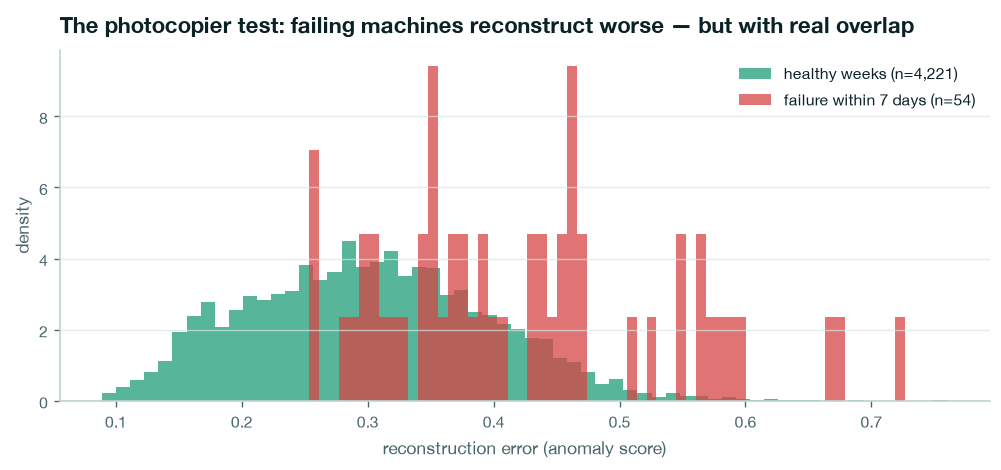

In [2]:
test = scores[scores["split"] == "test"]
healthy, failing = test[test["label"] == 0], test[test["label"] == 1]

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.hist(healthy["anomaly_score"], bins=60, density=True, alpha=.75,
        label=f"healthy weeks (n={len(healthy):,})", color="#1F9E78")
ax.hist(failing["anomaly_score"], bins=60, density=True, alpha=.75,
        label=f"failure within 7 days (n={len(failing)})", color="#D64545")
ax.set_xlabel("reconstruction error (anomaly score)")
ax.set_ylabel("density")
ax.set_title("The photocopier test: failing machines reconstruct worse — but with real overlap", loc="left")
ax.legend()
plt.show()

**Read it like this:** red (about to fail) sits clearly to the right of green —
the signal is real. But the overlap is heavy: plenty of healthy weeks look just
as "blurry" as failing ones. That overlap is exactly why the PR-AUC lands at
0.111 rather than something heroic — and part of it is by design: ~15% of
failures are sudden, with no sensor warning for ANY detector to find.

## Step 2 — One machine's story: the score rising before a real failure

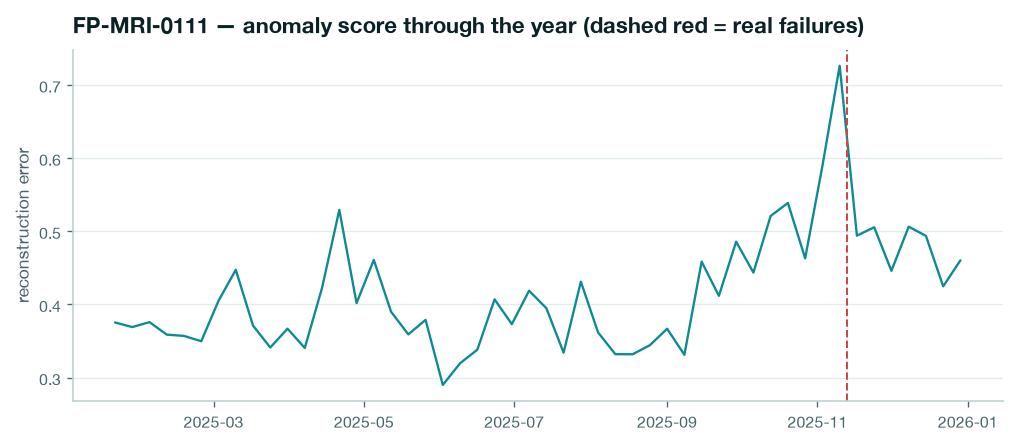

machine FP-MRI-0111: failures on 2025-11-13


In [3]:
fail_rows = scores[(scores["split"] == "test") & (scores["label"] == 1)]
mid = fail_rows.sort_values("anomaly_score", ascending=False)["machine_id"].iloc[0]
m = scores[scores["machine_id"] == mid].sort_values("date")

failures = pd.read_parquet(ML / "data" / "raw" / "failures.parquet")
f_dates = failures.loc[failures["machine_id"] == mid, "failure_date"]

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(m["date"], m["anomaly_score"], color="#0E8A92", lw=1.4)
for fd in f_dates:
    ax.axvline(fd, color="#D64545", ls="--", lw=1.2)
ax.set_title(f"{mid} — anomaly score through the year (dashed red = real failures)", loc="left")
ax.set_ylabel("reconstruction error")
plt.show()
print(f"machine {mid}: failures on", ", ".join(str(d.date()) for d in f_dates))

## Step 3 — The honest benchmark: same test window, same labels, same metric

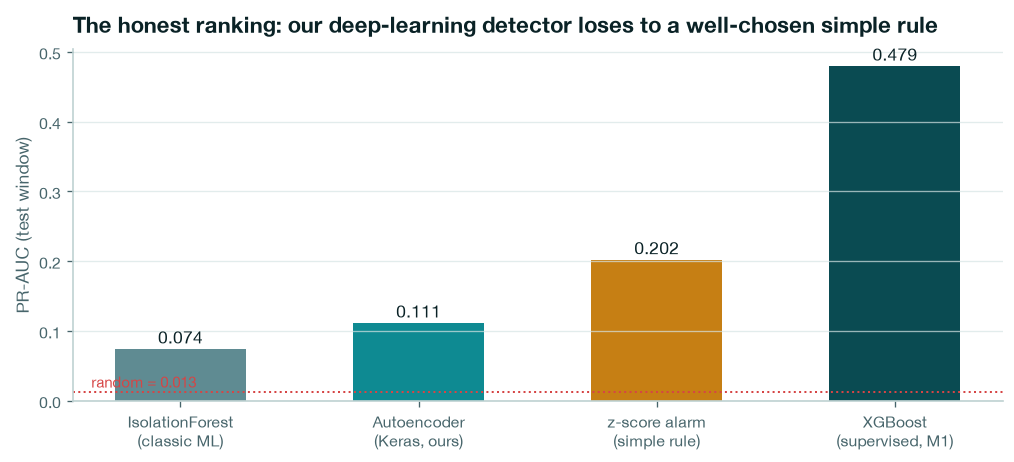

In [4]:
mm = meta["metrics"]
names = {
    "prauc::IsolationForest": "IsolationForest\n(classic ML)",
    "prauc::Autoencoder (Keras, reconstruction error)": "Autoencoder\n(Keras, ours)",
    "prauc::Rolling z-score alarm": "z-score alarm\n(simple rule)",
    "prauc::XGBoost (calibrated, supervised)": "XGBoost\n(supervised, M1)",
}
vals = [mm[k] for k in names]
colors = ["#5F8B92", "#0E8A92", "#C67F14", "#0A4B52"]

fig, ax = plt.subplots(figsize=(10, 3.8))
bars = ax.bar(list(names.values()), vals, color=colors, width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + .008, f"{v:.3f}", ha="center", fontsize=10.5)
ax.axhline(mm["prevalence_test"], color="#D64545", ls=":", lw=1.2)
ax.text(0.02, mm["prevalence_test"] + .006, f"random = {mm['prevalence_test']:.3f}",
        color="#D64545", fontsize=9, transform=ax.get_yaxis_transform())
ax.set_ylabel("PR-AUC (test window)")
ax.set_title("The honest ranking: our deep-learning detector loses to a well-chosen simple rule", loc="left")
plt.show()

## What this means (say it like this)

- "My autoencoder scored 0.111 — nine times better than random, better than
  IsolationForest, but **it lost to the per-sensor z-score alarm (0.202)**.
  I shipped that comparison instead of hiding it."
- **Why it lost (and why that's a good answer):** the autoencoder averages
  reconstruction error across all 196 inputs, so a slow drift in ONE sensor —
  which is exactly how most of this fleet's failures announce themselves —
  gets diluted by 195 well-reconstructed numbers. The z-score alarm looks at
  each sensor individually, so it's hand-shaped for precisely this failure
  signature. Generic model vs domain-fit rule: the rule won.
- **What I'd try next (roadmap, not built):** score by max per-sensor error
  instead of the mean (stops the dilution), one model per modality, a
  sequence model (LSTM autoencoder) for temporal shape, and a cost-based
  alert threshold like Module 1's.
- **Why it still earns its place:** it needs no labels. On a real fleet the
  labelled failures are a fraction of what goes wrong; a normality model is
  the net for the failure modes nobody has annotated. And methodologically it
  closes the loop: supervised (M1) + unsupervised (M2) + the discipline to
  benchmark both against simple baselines.

**The interview line that wins the room:** *"My deep-learning model lost to a
one-line statistical rule, and I'm showing you that result. If I hid it,
you shouldn't trust my $2.6M number either."*